# Discrete-Time Fourier Transform (DTFT)
Just transferring time domain to frequency domain.

## Definition
We define the discrete-time Fourier Transform of a sequence $x[n]$ as:

$$ X(e^{j\omega}) := \sum_{k=-\infty}^{\infty} x[k] e^{-j\omega k} $$

## Can We Recover $x[n]$ from $X(e^{j\omega})$?
The method to "go back" is to use the **Principle of Orthogonality**.

### Integral Representation:
$$ \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega = \int_{-\pi}^{\pi} \sum_{m=-\infty}^{\infty} x[m] e^{j\omega(n-m)} d\omega $$

### Interchanging Summation and Integration:
$$ \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega = \sum_{m=-\infty}^{\infty} x[m] \int_{-\pi}^{\pi} e^{j\omega(n-m)} d\omega $$

### Applying the Principle of Orthogonality:
$$
\int_{-\pi}^{\pi} e^{j\omega(n-m)} d\omega =
\begin{cases}
  2\pi, & \text{if } n = m \\
  0, & \text{if } n \neq m
\end{cases}
$$

### We get:
$$ x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega $$

## The Forward and Inverse DTFT Pair:
### Forward DTFT:
$$ X(e^{j\omega}) = \sum_{k=-\infty}^{\infty} x[k] e^{-j\omega k} $$

### Inverse DTFT:
$$ x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, convolve, lfilter
import mplcursors

### DTFT Function in python :

In [2]:
# --- DTFT Function ---
def dtft(x, n, w):
    """
    Computes the Discrete-Time Fourier Transform (DTFT).

    Evaluates the DTFT formula at a specified set of frequency points:
        X(e^jw) = sum[ x[n] * e^(-jwn) ]  for all n

    Uses NumPy broadcasting to compute the full sum efficiently in one
    operation — building an (N, M) matrix of all (n, w) combinations,
    scaling by sample values, then summing over the time axis.

    Parameters
    ----------
    x : array-like
        Signal sample values (real or complex).
    n : array-like
        Time indices corresponding to each sample in x.
    w : array-like
        Frequency points (omega) at which to evaluate the transform.

    Returns
    -------
    X : np.ndarray (complex128), shape (len(w),)
        Complex frequency spectrum. Take np.abs(X) for magnitude,
        np.angle(X) for phase.
    """
    x = np.array(x, dtype=np.complex128)
    n = np.array(n)
    w = np.array(w)
    X = np.sum(x[:, None] * np.exp(-1j * n[:, None] * w), axis=0)
    return X

## Constant Function
Let's start by creating a function that is all ones. Of course, we cannot have an infinite number of ones on our computer. So we can start with 1024 ones. Then we compute the DTFT function.

Plotting a magnitude spectrum in dB simply means we take 20 times log10 of the value. Recall that the DTFT is complex, so the np.abs() function computes the magnitude of the complex number and the function np.angle() computes the phase of the complex number.

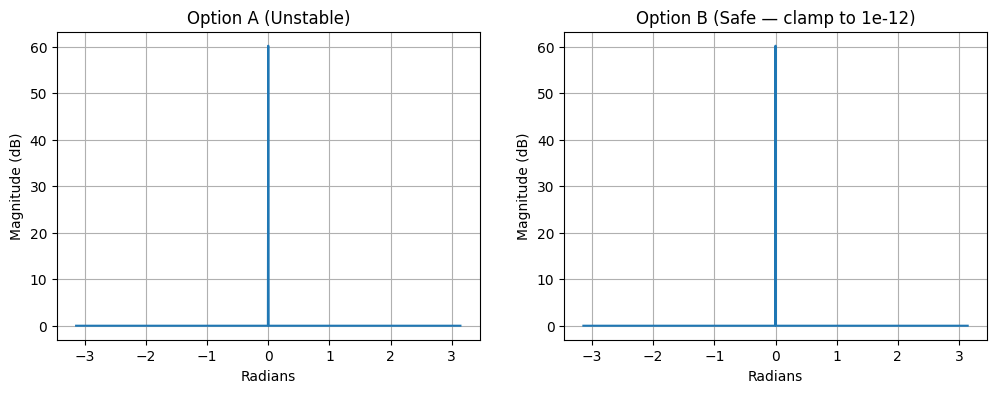

In [10]:
# --- Constant Function Example ---

# SAMPLE NUMBER (n) : ranges from 0 to 1024 (inclusive), creating a total of 1025 samples
n = np.arange(1025)

# SIGNAL (xn) : a constant function where every sample value is 1, matching the length of n
xn = np.ones_like(n)

# FREQUENCY POINTS (w) : 1025 points linearly spaced from -pi to pi, the integrating range for the DTFT
w = np.linspace(-np.pi, np.pi, 1025)

Xdtft = dtft(xn, n, w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Option A - INCOMPLETE, UNSTABLE FOR VERY SMALL VALUES
ax1.plot(w, 20 * np.log10(np.abs(Xdtft)))
ax1.set_title("Option A (Unstable)")
ax1.set_xlabel("Radians")
ax1.set_ylabel("Magnitude (dB)")
ax1.grid(True)

# Option B - FULL MAGNITUDE IN DB FUNCTION (GO WITH THIS OPTION)
mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))
ax2.plot(w, mag_db)
ax2.set_title("Option B (Safe — clamp to 1e-12)")
ax2.set_xlabel("Radians")
ax2.set_ylabel("Magnitude (dB)")
ax2.grid(True)

Create the signal $ x[n] = \cos(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

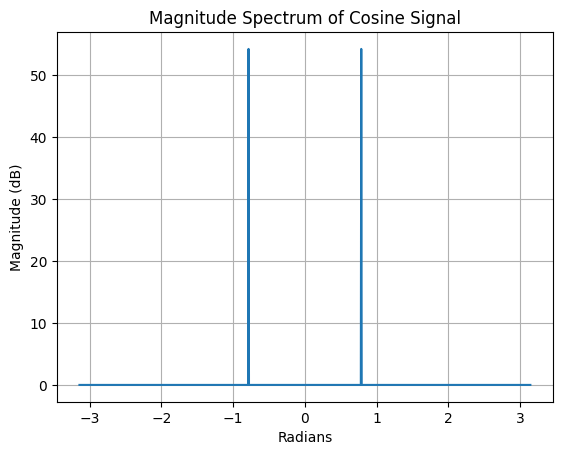

In [11]:
n = np.arange(1025) # Sample number from 0 to 1024 (inclusive)
xn = np.cos(np.pi/4 * n) # Cosine signal with frequency pi/4
w = np.linspace(-np.pi, np.pi, 1025) # Integrating range for DTFT
Xdtft = dtft(xn, n, w)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Cosine Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Create the signal $x[n] = \sin(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

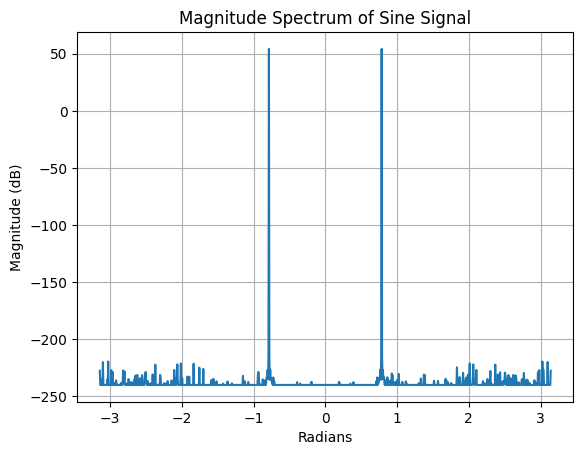

In [12]:
n = np.arange(1025) # Sample number from 0 to 1024 (inclusive)
xn = np.sin(np.pi/4 * n) # Sine signal with frequency pi/4
w = np.linspace(-np.pi, np.pi, 1025) # Integrating range for DTFT
Xdtft = dtft(xn, n, w)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Sine Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

## Exploring the Dirichlet Kernel Lobes
Create the signal $x[n] = \sin(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

This time increase the frequency resolution by letting $\omega$ have 20001 points. Because the sinuoid does not continue infinitely in time, the peak in the frequency spectrum is not pure. The sinuoidal signal is as if it has been windowed. This produces the Dirichlet kernel lobes. You should see this clearly if you
limit the x-axis to $\pi - 0.2$ to $\pi + 0.2$ and limit the y-axis to $-80$ to $5$.

NOTE: We are using a different mag_dB function here, one that is normalized.

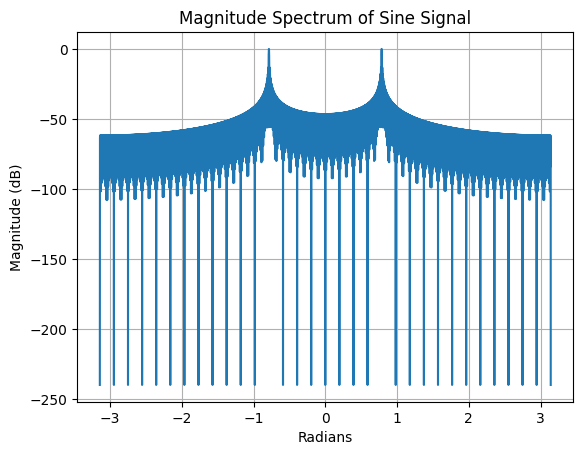

In [17]:
n = np.arange(1025)
xn = np.sin(np.pi/4 * n)
w = np.linspace(-np.pi, np.pi, 20001) # Omega now has 20,001 points for a smoother plot
Xdtft = dtft(xn, n, w)

# FULL MAGNITUDE IN DB (NORMALIZED) :
mag = np.abs(Xdtft)
mag = mag / np.max(mag) # Normalize to max value (0 dB)
mag_db = 20 * np.log10(np.maximum(mag, 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Sine Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Zoomed plot to +π/4

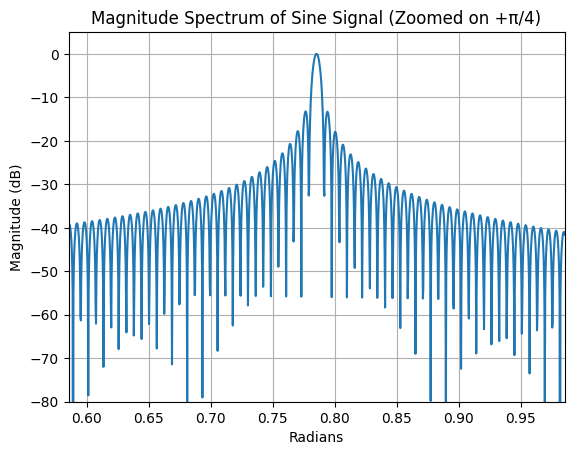

In [18]:
plt.figure()
plt.plot(w, mag_db)

#Plot limits, zoomed on +π/4
plt.xlim([np.pi/4 - 0.2, np.pi/4 + 0.2])
plt.ylim([-80, 5])

plt.title("Magnitude Spectrum of Sine Signal (Zoomed on +π/4)")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Create the signal $x[n] = e^{j\omega_0\,n}$  with $\omega_0 = \pi/4$ for n = 0 to 1024. Compute the DTFT and plot the magnitude spectrum and phase spectrum.

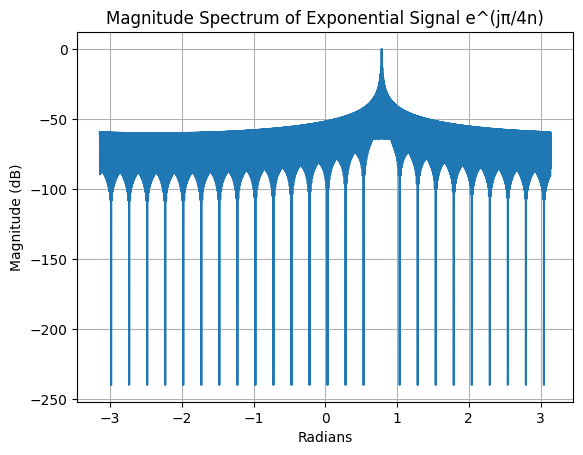

In [19]:
n = np.arange(1025)
xn = np.exp(1j * np.pi/4 * n) #EXPONENTIAL SIGNAL WITH FREQUENCY +π/4
w = np.linspace(-np.pi, np.pi, 20001)
Xdtft = dtft(xn, n, w)

mag = np.abs(Xdtft)
mag = mag / np.max(mag)
mag_db = 20 * np.log10(np.maximum(mag, 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Exponential Signal e^(jπ/4n)")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Notice that the symmetry is gone. There is a single peak in the spectrum.

## Mixture of Three Sinusoids
Let's do a more complicated and fun example. Let's generate three cosine signals at different frequencies.

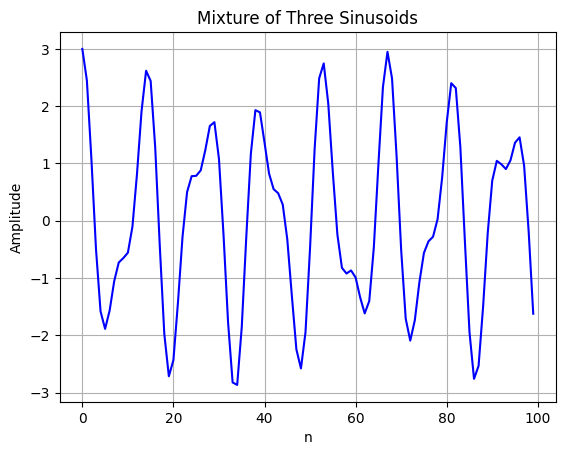

In [32]:
# --- Mixture of Three Sinusoids ---
np.random.seed()  # Different frequencies each run
n = np.arange(100)
w0 = -np.pi + (2 * np.pi) * np.random.rand(3)  # 3 random frequencies
x1 = np.cos(w0[0] * n)
x2 = np.cos(w0[1] * n)
x3 = np.cos(w0[2] * n)
x = x1 + x2 + x3

plt.figure()
plt.plot(n, x, 'b', linewidth=1.5)
plt.title("Mixture of Three Sinusoids")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Compute the DTFT and plot the magnitude spectrum and see if you can identify the three frequencies.

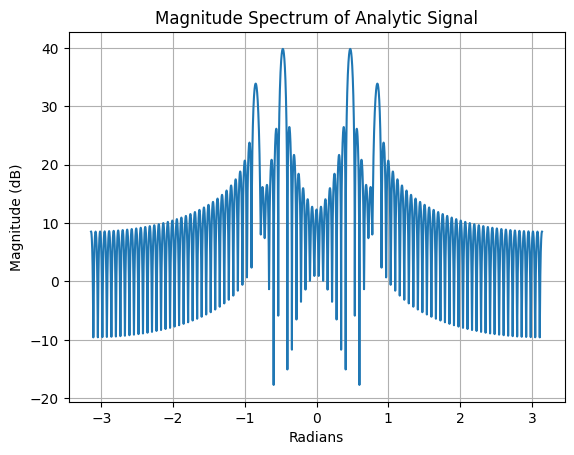

In [33]:
w = np.linspace(-np.pi, np.pi, 20001)
Xdtft = dtft(x, n, w) # x = x1 + x2 + x3 (The mixture of three sinusoids)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Analytic Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

Check if your identification of the three frequencies is correct. We plot the three signals separately with the frequency printed out.

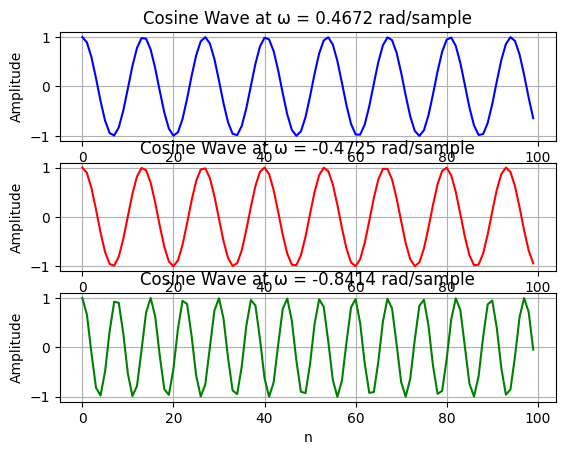

In [34]:
# Plot the signals
plt.figure()
plt.subplot(3, 1, 1)
plt.plot(n, x1, 'b', linewidth=1.5)
plt.title(f'Cosine Wave at ω = {w0[0]:.4f} rad/sample')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(n, x2, 'r', linewidth=1.5)
plt.title(f'Cosine Wave at ω = {w0[1]:.4f} rad/sample')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(n, x3, 'g', linewidth=1.5)
plt.title(f'Cosine Wave at ω = {w0[2]:.4f} rad/sample')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid()

## Analyzing Cyclical Data with FFT
For almost 300 years, astronomers have tabulated the number and size of sunspots using the Zurich sunspot relative number. Plot the Zurich number over approximately the years 1700 to 2000.

We are using Fourier to analyse an event that happened over a period of time

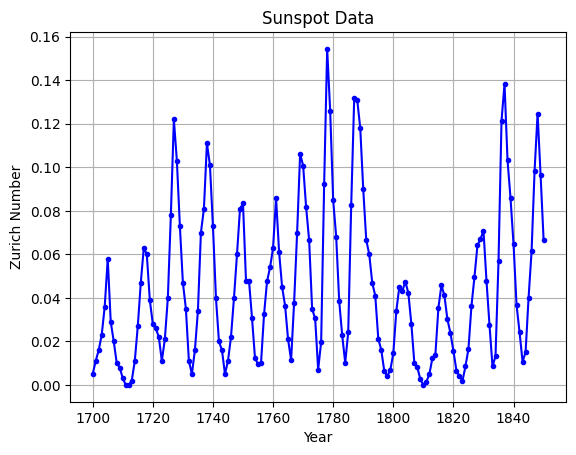

In [38]:
# --- Sunspot Data Analysis ---
# Define the sunspot data
sunspot = np.array([
    [1700, 0.0050], [1701, 0.0110], [1702, 0.0160], [1703, 0.0230], [1704, 0.0360], 
    [1705, 0.0580], [1706, 0.0290], [1707, 0.0200], [1708, 0.0100], [1709, 0.0080], 
    [1710, 0.0030], [1711, 0.0000], [1712, 0.0000], [1713, 0.0020], [1714, 0.0110], 
    [1715, 0.0270], [1716, 0.0470], [1717, 0.0630], [1718, 0.0600], [1719, 0.0390], 
    [1720, 0.0280], [1721, 0.0260], [1722, 0.0220], [1723, 0.0110], [1724, 0.0210], 
    [1725, 0.0400], [1726, 0.0780], [1727, 0.1220], [1728, 0.1030], [1729, 0.0730], 
    [1730, 0.0470], [1731, 0.0350], [1732, 0.0110], [1733, 0.0050], [1734, 0.0160], 
    [1735, 0.0340], [1736, 0.0700], [1737, 0.0810], [1738, 0.1110], [1739, 0.1010], 
    [1740, 0.0730], [1741, 0.0400], [1742, 0.0200], [1743, 0.0160], [1744, 0.0050], 
    [1745, 0.0110], [1746, 0.0220], [1747, 0.0400], [1748, 0.0600], [1749, 0.0809], 
    [1750, 0.0834], [1751, 0.0477], [1752, 0.0478], [1753, 0.0307], [1754, 0.0122], 
    [1755, 0.0096], [1756, 0.0102], [1757, 0.0324], [1758, 0.0476], [1759, 0.0540], 
    [1760, 0.0629], [1761, 0.0859], [1762, 0.0612], [1763, 0.0451], [1764, 0.0364], 
    [1765, 0.0209], [1766, 0.0114], [1767, 0.0378], [1768, 0.0698], [1769, 0.1061], 
    [1770, 0.1008], [1771, 0.0816], [1772, 0.0665], [1773, 0.0348], [1774, 0.0306], 
    [1775, 0.0070], [1776, 0.0198], [1777, 0.0925], [1778, 0.1544], [1779, 0.1259], 
    [1780, 0.0848], [1781, 0.0681], [1782, 0.0385], [1783, 0.0228], [1784, 0.0102], 
    [1785, 0.0241], [1786, 0.0829], [1787, 0.1320], [1788, 0.1309], [1789, 0.1181], 
    [1790, 0.0899], [1791, 0.0666], [1792, 0.0600], [1793, 0.0469], [1794, 0.0410], 
    [1795, 0.0213], [1796, 0.0160], [1797, 0.0064], [1798, 0.0041], [1799, 0.0068], 
    [1800, 0.0145], [1801, 0.0340], [1802, 0.0450], [1803, 0.0431], [1804, 0.0475], 
    [1805, 0.0422], [1806, 0.0281], [1807, 0.0101], [1808, 0.0081], [1809, 0.0025], 
    [1810, 0.0000], [1811, 0.0014], [1812, 0.0050], [1813, 0.0122], [1814, 0.0139], 
    [1815, 0.0354], [1816, 0.0458], [1817, 0.0411], [1818, 0.0301], [1819, 0.0239], 
    [1820, 0.0156], [1821, 0.0066], [1822, 0.0040], [1823, 0.0018], [1824, 0.0085], 
    [1825, 0.0166], [1826, 0.0363], [1827, 0.0496], [1828, 0.0642], [1829, 0.0670], 
    [1830, 0.0709], [1831, 0.0478], [1832, 0.0275], [1833, 0.0085], [1834, 0.0132], 
    [1835, 0.0569], [1836, 0.1215], [1837, 0.1383], [1838, 0.1032], [1839, 0.0857], 
    [1840, 0.0646], [1841, 0.0367], [1842, 0.0242], [1843, 0.0107], [1844, 0.0150], 
    [1845, 0.0401], [1846, 0.0615], [1847, 0.0985], [1848, 0.1247], [1849, 0.0963], 
    [1850, 0.0666]
])
year = sunspot[:,0]
relNums = sunspot[:,1]

plt.figure()
plt.plot(year, relNums, 'b.-')
plt.xlabel("Year")
plt.ylabel("Zurich Number")
plt.title("Sunspot Data")
plt.grid()
plt.show()

To take a closer look at the cyclical nature of sunspot activity, plot the first 50 years of data, label your plot

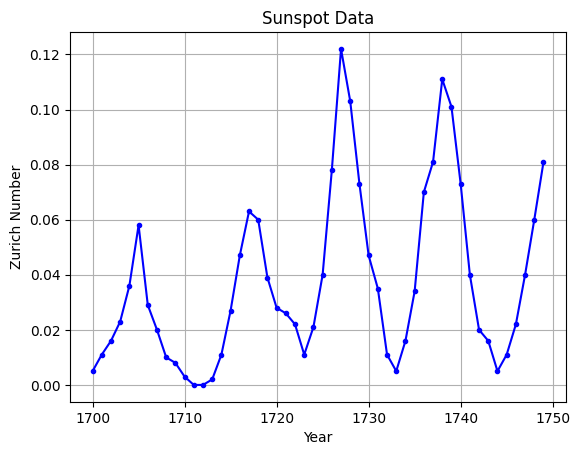

In [ ]:
year50 = sunspot[:,0][:50]
relNums50 = sunspot[:,1][:50]

plt.figure()
plt.plot(year50, relNums50, 'b.-')
plt.xlabel("Year")
plt.ylabel("Zurich Number")
plt.title("Sunspot Data")
plt.grid()
plt.show()

Compute the DTFT of the signal. Use $\omega = \pi * [-1 : 1/256 : 1]$.

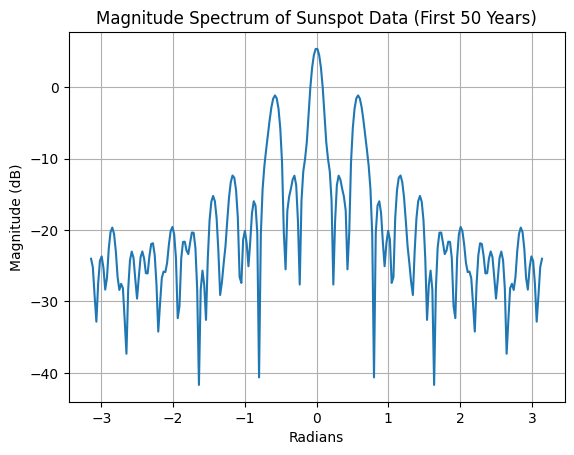

In [42]:
year50 = sunspot[:,0][:50]
relNums50 = sunspot[:,1][:50]

n = np.arange(len(relNums50))
w = np.linspace(-np.pi, np.pi, 256) # omega = 256 points from -pi to pi for a smoother plot
Xdtft = dtft(relNums50, n, w)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Sunspot Data (First 50 Years)")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Plot the power spectrum as a function of frequency measured in cycles per year. Plot only the positive frequency part of the magnitude spectrum because the spectrum is symmetric

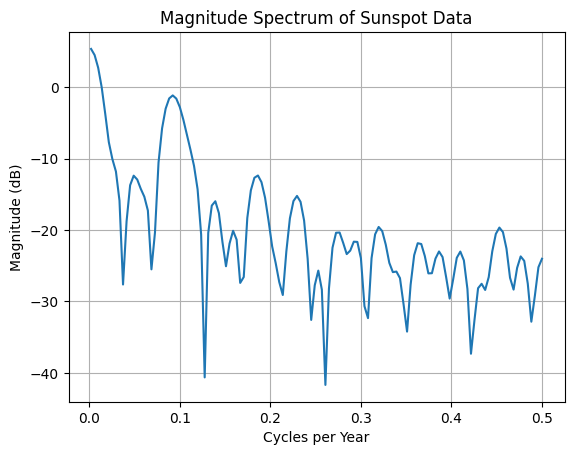

In [43]:
# Convert angular frequency to cycles per year
f = w / (2 * np.pi)

plt.figure()
plt.plot(f[f >= 0], mag_db[f >= 0])  # Plot only the positive frequencies
plt.title("Magnitude Spectrum of Sunspot Data")
plt.xlabel("Cycles per Year")
plt.ylabel("Magnitude (dB)")
plt.grid()

For a view of the cyclical activity that is easier to interpret, plot the magnitude spectrum as a function of period, measured in years per cycle. Restrict the plot to only 25 Years Per Cycle. Identify the maximum number of Years per Cycle for Sun Spot Activity.

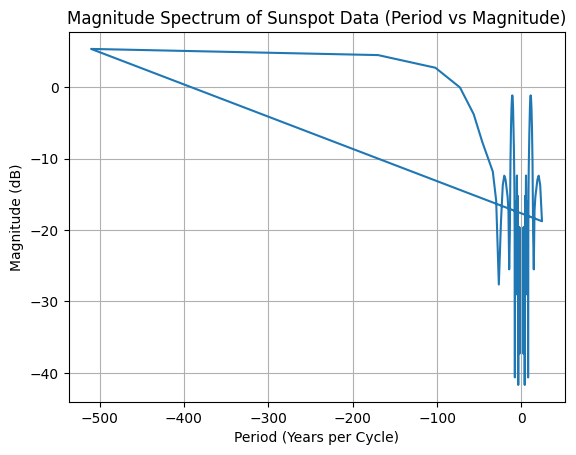

In [ ]:
# Years per cycle (period) = 1 / frequency
period = 1 / f

restricted_period = period[period <= 25] # Focus on periods up to 25 years per cycle
mag_db_restricted = mag_db[1/f <= 25] # Corresponding magnitude values for the restricted period range

plt.figure()
plt.plot(restricted_period, mag_db_restricted)
plt.title("Magnitude Spectrum of Sunspot Data (Period vs Magnitude)")
plt.xlabel("Period (Years per Cycle)")
plt.ylabel("Magnitude (dB)")
plt.grid()

Plot limited to x values 0 to 25.

Basically positive and up to 25 years per cycle.

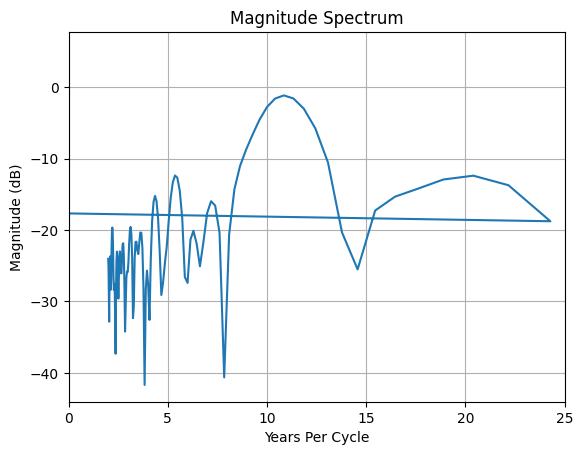

In [48]:
plt.figure()
plt.plot(restricted_period, mag_db_restricted)
plt.title("Magnitude Spectrum")
plt.xlabel("Years Per Cycle")
plt.ylabel("Magnitude (dB)")

# Plot limits, 0 <= Years Per Cycle <= 25
plt.xlim([0, 25])

plt.grid()